In [1]:
import pandas as pd
from data_preparation import Data_Preparation as dp

prep = dp()
X, y = prep.prepare_data_general_pump_time()

In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Assuming X is your feature matrix and y is your target variable
# First split into training and temp (validation + test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train,X_val,y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)
X_train

,hours_since_watering,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,deficit_x_temp,deficit_x_light,deficit_x_air,et_approx
35306,122.0,13.26,0.712903,1.91,1.93,941.75,25.3266,12487.605,25.5918,11914.301450
65243,72.0,12.70,0.717514,0.64,0.51,1326.71,8.1280,16849.217,6.4770,9974.152438
41113,188.0,13.88,0.354082,0.20,-2.11,-553.20,2.7760,-7678.416,-29.2868,0.000000
47440,45.0,10.78,0.609040,-0.91,-1.26,-7397.60,-9.8098,-79746.128,-13.5828,0.000000
43119,165.0,12.90,0.720670,0.27,0.44,-7500.20,3.4830,-96752.580,5.6760,0.000000
...,...,...,...,...,...,...,...,...,...,...
73509,214.0,15.05,0.328603,-3.37,-0.46,-489.50,-50.7185,-7366.975,-6.9230,0.000000
32078,38.0,12.70,0.717514,0.25,-0.02,1337.07,3.1750,16980.789,-0.2540,9587.321104
15991,1066.0,-6.40,-0.088643,-3.39,0.49,-1026.50,21.6960,6569.600,-3.1360,0.000000
51634,324.0,12.64,0.706145,0.09,0.35,-7500.20,1.1376,-94802.528,4.4240,0.000000


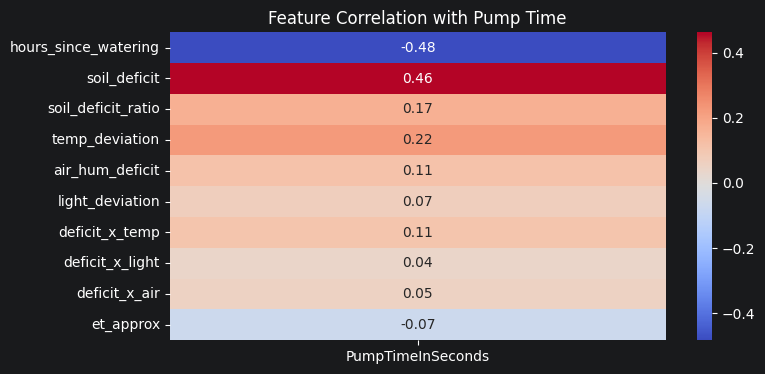

In [3]:
from sklearn.metrics import confusion_matrix, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

In [ ]:
import xgboost as xgb
import random
from sklearn.metrics import mean_absolute_error
random.seed(42)
# convert to GPU DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

param_grid = {
    "max_depth": [3, 6, 9, 12, 15],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.01, 0.1, 1, 10],
    "reg_lambda": [0.1, 1, 10, 100],
}

def sample_params():
    return {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "device": "cuda",
        "max_depth": random.choice(param_grid["max_depth"]),
        "learning_rate": random.choice(param_grid["learning_rate"]),
        "subsample": random.choice(param_grid["subsample"]),
        "colsample_bytree": random.choice(param_grid["colsample_bytree"]),
        "min_child_weight": random.choice(param_grid["min_child_weight"]),
        "reg_alpha": random.choice(param_grid["reg_alpha"]),
        "reg_lambda": random.choice(param_grid["reg_lambda"]),
    }

best_score = float("inf")
best_params = None
best_model = None
best_num_boost_round = None
N_TRIALS = 40

for i in range(N_TRIALS):
    params = sample_params()

    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=500,
        nfold=3,
        early_stopping_rounds=20,
        metrics="mae",
        seed=42,
        verbose_eval=False
    )

    score = cv_results["test-mae-mean"].min()

    print(f"Trial {i+1}/{N_TRIALS} → MAE: {score:.4f}")

    if score < best_score:
        best_score = score
        best_params = params
        best_num_boost_round = len(cv_results)

# train final model
final_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=best_num_boost_round,
    evals=[(dval, "val")],
    verbose_eval=False
)

# predictions
preds = final_model.predict(dval)

print(best_params)
print("MAE:", mean_absolute_error(y_val, preds))

Trial 1/40 → MAE: 2.0127
Trial 2/40 → MAE: 2.0128
Trial 3/40 → MAE: 1.9959
Trial 4/40 → MAE: 2.1949
Trial 5/40 → MAE: 2.0080
Trial 6/40 → MAE: 2.0220
Trial 7/40 → MAE: 2.0287
Trial 8/40 → MAE: 2.1216
Trial 9/40 → MAE: 2.0038
Trial 10/40 → MAE: 2.0361
Trial 11/40 → MAE: 2.0161
Trial 12/40 → MAE: 2.0391
Trial 13/40 → MAE: 2.0187
Trial 14/40 → MAE: 1.9997
Trial 15/40 → MAE: 2.0055
Trial 16/40 → MAE: 2.1560
Trial 17/40 → MAE: 2.2010


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# evaluate
preds_val = final_model.predict(dval)
preds_test = final_model.predict(dtest)

print(f"\nBest params: {best_params}")
print(f"Best num_boost_round: {best_num_boost_round}")
print(f"\nVal  MAE: {mean_absolute_error(y_val, preds_val):.3f}")
print(f"Val  MSE: {mean_squared_error(y_val, preds_val):.3f}")
print(f"Val  R²:  {r2_score(y_val, preds_val):.4f}")
print(f"\nTest MAE: {mean_absolute_error(y_test, preds_test):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, preds_test):.3f}")
print(f"Test R²:  {r2_score(y_test, preds_test):.4f}")

import os
# Delete old model before training
if os.path.exists("../models/xgb_model.ubj"):
    os.remove("../models/xgb_model.ubj")
    print("Old model deleted")


os.makedirs("../models", exist_ok=True)
final_model.save_model("../models/xgb_model.ubj")
print("\nModel saved.")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ── 1. Scale + convert to tensors ────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

def to_tensor(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    )

train_loader = DataLoader(to_tensor(X_train_s, y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(to_tensor(X_val_s,   y_val),   batch_size=128)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# ── 2. Model ──────────────────────────────────────────────────────────────────
class PlantNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 32),          nn.ReLU(), nn.BatchNorm1d(32),  nn.Dropout(0.2),
            nn.Linear(32, 16),           nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

model = PlantNet(X_train_s.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── 3. Train loop ─────────────────────────────────────────────────────────────
EPOCHS = 2
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # train
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(sum(batch_losses) / len(batch_losses))

    # validate
    model.eval()
    with torch.no_grad():
        batch_losses = []
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            batch_losses.append(criterion(model(xb), yb).item())
    val_losses.append(sum(batch_losses) / len(batch_losses))
    scheduler.step(val_losses[-1])

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}")

# ── 4. Evaluate on val ────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds = model(torch.tensor(X_val_s, dtype=torch.float32).to(device))
    preds = preds.cpu().numpy().flatten()

mae = mean_absolute_error(y_val, preds)
r2  = r2_score(y_val, preds)
print(f"\nVal MAE: {mae:.3f}    R²: {r2:.4f}")

# ── 5. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PyTorch Neural Network — Quick Demo", fontsize=14, fontweight="bold")

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_title("Loss Curves (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_val, preds, alpha=0.4, s=15, color="darkorange")
lims = [min(y_val.min(), preds.min()), max(y_val.max(), preds.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
axes[1].set_title(f"Predicted vs Actual  (R²={r2:.3f})")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()